## 1. Load model-ready data

In [1]:
# Load the sequences saved in Phase 2
import numpy as np
import tensorflow as tf

# Fix the random seeds so results are reproducible
tf.keras.utils.set_random_seed(42)

train = np.load("../data/model_ready_data/train.npz")
val = np.load("../data/model_ready_data/val.npz")
test = np.load("../data/model_ready_data/test.npz")

X_train, y_train = train["X"], train["y"]
X_val, y_val = val["X"], val["y"]
X_test, y_test = test["X"], test["y"]

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, "y_test: ", y_test.shape)

X_train: (1450, 60, 5) y_train: (1450,)
X_val:   (250, 60, 5) y_val:   (250,)
X_test:  (179, 60, 5) y_test:  (179,)


```Text
Phase 2
   ↓
train.npz / val.npz / test.npz
   ↓
np.load()
   ↓
X and y extract
   ↓
Shape check
   ↓
Ready for LSTM Model

# How LSTM Works Internally

```Text
Current Input
     +
Previous Hidden State
     ↓
   LSTM Cell
     ↓
┌─────────────────────┐
│ Forget Gate         │
│ Input Gate          │
│ Cell State Update   │
│ Output Gate         │
└─────────────────────┘
     ↓
New Cell State
New Hidden State

In [2]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense

# Input: 60 days x 5 features
# return_sequences=True passes the full sequence to the next LSTM layer,
# the last LSTM returns only its final output
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(100, return_sequences=True),
    Dropout(0.2),
    LSTM(100, return_sequences=True),
    Dropout(0.2),
    LSTM(100, return_sequences=True),
    Dropout(0.2),
    LSTM(100),
    Dropout(0.2),
    Dense(1),   # predicted (scaled) Close price of the next day
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 100)        │        42,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 60, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 283,701 (1.08 MB)

 Trainable params: 283,701 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# Adam optimizer and Mean Squared Error loss (regression on the scaled Close price)
# MAE is tracked as an extra, easier to read metric
model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"],
)

print("Model compiled")

Model compiled


# Model Training Steps
```` Text
X_train + y_train
       ↓
    LSTM Model
       ↓
   Prediction
       ↓
     MSE Loss
       ↓
     Adam Optimizer
       ↓
    Update Weights
       ↓
   Next Batch
       ↓
   Next Epoch
       ↓
Validation Loss Check
       ↓
Improve? ── Yes → Continue
   │
   No
   ↓
15 epochs no improvement
   ↓
Stop Training
   ↓
Restore Best Weights
   ↓
Save model.keras

In [4]:
from tensorflow.keras.callbacks import EarlyStopping

# Stop training when validation loss has not improved for 15 epochs
# and go back to the weights from the best epoch
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1,
)

# Save the trained model
model.save("../saved_models/lstm_model.keras")

Epoch 1/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 182ms/step - loss: 0.0332 - mean_absolute_error: 0.1271 - val_loss: 0.1162 - val_mean_absolute_error: 0.2549
Epoch 2/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 164ms/step - loss: 0.0061 - mean_absolute_error: 0.0587 - val_loss: 0.1030 - val_mean_absolute_error: 0.2445
Epoch 3/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 152ms/step - loss: 0.0036 - mean_absolute_error: 0.0445 - val_loss: 0.0660 - val_mean_absolute_error: 0.1884
Epoch 4/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 144ms/step - loss: 0.0033 - mean_absolute_error: 0.0425 - val_loss: 0.0429 - val_mean_absolute_error: 0.1509
Epoch 5/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 144ms/step - loss: 0.0031 - mean_absolute_error: 0.0408 - val_loss: 0.0294 - val_mean_absolute_error: 0.1249
Epoch 6/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 172ms/step - loss: 0.0029 - mean_absolute_error: 0.0401 - val_loss: 0.0276 - val_mean_absolute_error: 0.1212
Epoch 7/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 175ms/step - loss: 0.0027 - mean_absolute_error: 0.0

Best epoch: 22
Best validation loss: 0.0072


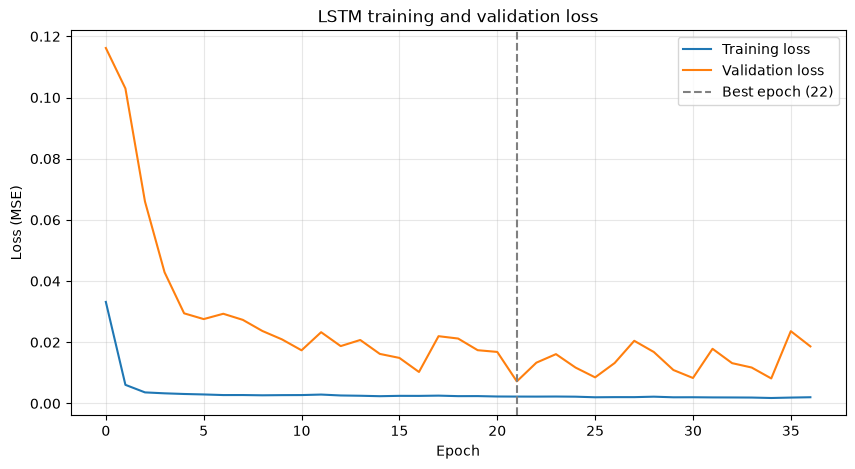

In [5]:
import matplotlib.pyplot as plt

# Epoch with the lowest validation loss (weights from this epoch were restored)
best_epoch = int(np.argmin(history.history["val_loss"])) + 1
print("Best epoch:", best_epoch)
print("Best validation loss:", round(min(history.history["val_loss"]), 5))

plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.axvline(best_epoch - 1, color="gray", linestyle="--", label=f"Best epoch ({best_epoch})")
plt.title("LSTM training and validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig("../results/plots/training_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
import joblib
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Scaler saved in Phase 2 (fitted on the training data, 5 feature columns)
scaler = joblib.load("../saved_models/scaler.pkl")

# Position of Close in [Open, High, Low, Close, Volume]
close_idx = 3

def inverse_close(scaled_close):
    # The scaler expects 5 columns, so put Close in a dummy array,
    # inverse transform, and take the Close column back out
    dummy = np.zeros((len(scaled_close), 5))
    dummy[:, close_idx] = scaled_close
    return scaler.inverse_transform(dummy)[:, close_idx]

results = {}
for name, X, y in [("Train", X_train, y_train),
                   ("Validation", X_val, y_val),
                   ("Test", X_test, y_test)]:
    pred = inverse_close(model.predict(X, verbose=0).flatten())
    actual = inverse_close(y)
    results[name] = (actual, pred)

    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    print(f"{name:10s} RMSE: {rmse:6.2f} USD | MAE: {mae:6.2f} USD | MAPE: {mape:5.2f}%")

Train      RMSE:   5.22 USD | MAE:   3.85 USD | MAPE:  3.50%
Validation RMSE:  12.51 USD | MAE:   9.15 USD | MAPE:  4.11%
Test       RMSE:  31.68 USD | MAE:  27.25 USD | MAPE:  7.78%


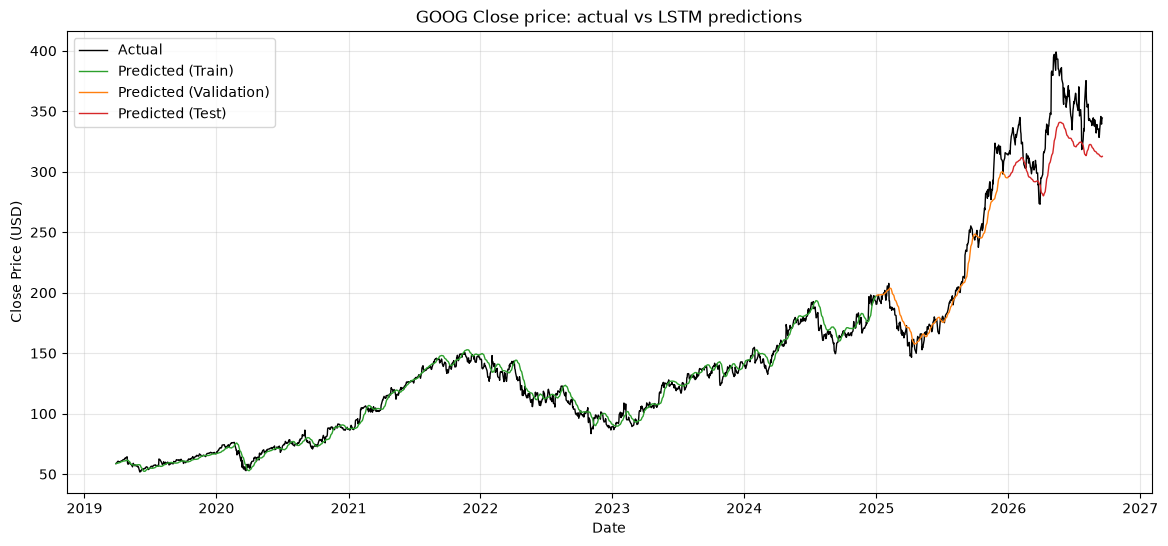

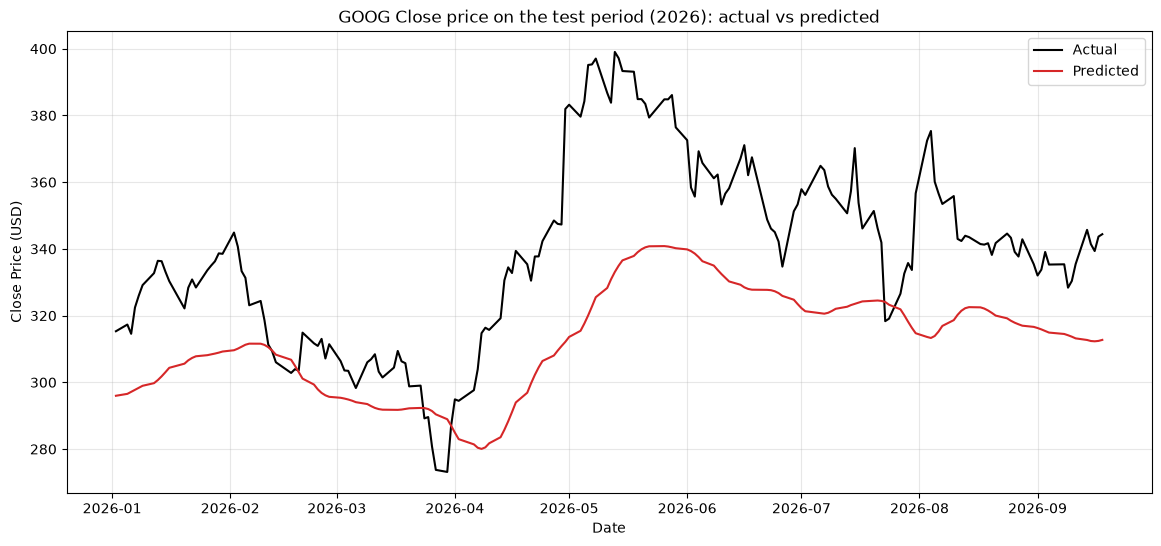

In [8]:
# Dates of each split's targets (saved in Phase 2)
dates = {
    "Train": train["dates"],
    "Validation": val["dates"],
    "Test": test["dates"],
}
colors = {"Train": "tab:green", "Validation": "tab:orange", "Test": "tab:red"}

# Plot 1: full timeline, actual vs predicted for all three splits
plt.figure(figsize=(14, 6))
all_dates = np.concatenate([dates[n] for n in ["Train", "Validation", "Test"]])
all_actual = np.concatenate([results[n][0] for n in ["Train", "Validation", "Test"]])
plt.plot(all_dates, all_actual, color="black", linewidth=1, label="Actual")

for name in ["Train", "Validation", "Test"]:
    plt.plot(dates[name], results[name][1], color=colors[name], linewidth=1, label=f"Predicted ({name})")

plt.title("GOOG Close price: actual vs LSTM predictions")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("../results/plots/predictions_full.png", dpi=150, bbox_inches="tight")
plt.show()

# Plot 2: zoom on the test period only
plt.figure(figsize=(14, 6))
plt.plot(dates["Test"], results["Test"][0], color="black", label="Actual")
plt.plot(dates["Test"], results["Test"][1], color="tab:red", label="Predicted")
plt.title("GOOG Close price on the test period (2026): actual vs predicted")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("../results/plots/predictions_test.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# Naive baseline: predict that the next day's Close equals the last day in the input window
print("Naive baseline (tomorrow's Close = today's Close)")
for name, X in [("Train", X_train), ("Validation", X_val), ("Test", X_test)]:
    actual = results[name][0]
    naive = inverse_close(X[:, -1, close_idx])   # Close of the last day in each 60-day window

    rmse = np.sqrt(mean_squared_error(actual, naive))
    mae = mean_absolute_error(actual, naive)
    mape = np.mean(np.abs((actual - naive) / actual)) * 100
    print(f"{name:10s} RMSE: {rmse:6.2f} USD | MAE: {mae:6.2f} USD | MAPE: {mape:5.2f}%")

Naive baseline (tomorrow's Close = today's Close)
Train      RMSE:   2.20 USD | MAE:   1.53 USD | MAPE:  1.39%
Validation RMSE:   4.20 USD | MAE:   3.03 USD | MAPE:  1.46%
Test       RMSE:   6.88 USD | MAE:   4.87 USD | MAPE:  1.43%
